# Persiapan Lingkungan
Menginstal pustaka yang diperlukan untuk proses Natural Language Processing ringan (termasuk konversi emoji).

In [25]:
!pip install pandas numpy emoji

# Minggu 3-4: Data Profiling
Menganalisis seberapa kotor data, menghitung duplikat, dan mengidentifikasi noise.

In [26]:
import pandas as pd
import numpy as np
import re
import string
import emoji
from collections import Counter

# Load dataset
df = pd.read_csv('../data/raw/data_komentar_jepang.csv')
print("Total data awal:", df.shape[0])
df.head()

Total data awal: 1339


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2037800146562638232,Sat Mar 28 07:53:10 +0000 2026,0,"Dalam rencana tersebut, pemerintah menyoroti b...",2037800149406408931,NaN,podcast_tyler,in,NaN,0,1,0,NaN,1.446295e+18,NaN
1,2032971532193165786,Sun Mar 15 00:06:00 +0000 2026,0,2️⃣ Kenapa Jepang membuat sistem ini?\n\nJumla...,2032971540908974570,NaN,kangende3,in,NaN,0,1,0,NaN,2.025482e+18,NaN
2,2031106344842047710,Mon Mar 09 20:34:23 +0000 2026,10,tahun lalu ada kasus maling di bali yg pelakun...,2031106344842047710,NaN,NaN,in,NaN,0,0,1,NaN,1.452802e+18,NaN
3,2030966433790984303,Mon Mar 09 11:18:26 +0000 2026,9278,If you are a foreigner attending a concert on ...,2030966433790984303,NaN,NaN,en,NaN,87,20,1905,NaN,3.186445e+09,NaN
4,2029263494042861773,Wed Mar 04 18:31:35 +0000 2026,0,Turis dari Jepang &amp; Korea hampir sama yait...,2029263500376166808,NaN,YunazKaraman,in,NaN,0,1,0,NaN,3.276004e+09,NaN


In [27]:
# 1. Menghitung persentase data duplikat
total_data = len(df)
duplikat_teks = df['full_text'].duplicated().sum()
persentase_duplikat = (duplikat_teks / total_data) * 100

print(f"Jumlah data duplikat pada teks: {duplikat_teks}")
print(f"Persentase data duplikat: {persentase_duplikat:.2f}%")

Jumlah data duplikat pada teks: 108
Persentase data duplikat: 8.07%


In [28]:
# 2. Identifikasi Noise (Emoji, Link, Mention)
def count_noise(text):
    if not isinstance(text, str):
        return 0, 0, 0
    # Hitung emoji
    emojis = emoji.emoji_list(text)
    jml_emoji = len(emojis)
    # Hitung link
    links = len(re.findall(r'http\S+|www\.\S+', text))
    # Hitung mention
    mentions = len(re.findall(r'@\w+', text))
    return jml_emoji, links, mentions

df['jml_emoji'], df['jml_link'], df['jml_mention'] = zip(*df['full_text'].apply(count_noise))

print("Total tweet mengandung emoji berlebihan (>3):", (df['jml_emoji'] > 3).sum())
print("Total tweet mengandung link:", (df['jml_link'] > 0).sum())
print("Total tweet mengandung mention:", (df['jml_mention'] > 0).sum())

Total tweet mengandung emoji berlebihan (>3): 8
Total tweet mengandung link: 458
Total tweet mengandung mention: 446


In [29]:
# 3. Mencari kata-kata gaul dan kata yang paling sering muncul
all_text = ' '.join(df['full_text'].dropna().astype(str).tolist()).lower()
# Hapus tanda baca sederhana untuk melihat frekuensi kata
all_text_clean = re.sub(f'[{re.escape(string.punctuation)}]', '', all_text)
words = all_text_clean.split()
word_freq = Counter(words)
print("20 Kata paling sering muncul secara umum:")
print(word_freq.most_common(20))

20 Kata paling sering muncul secara umum:
[('jepang', 799), ('turis', 754), ('the', 700), ('to', 550), ('di', 542), ('japan', 540), ('a', 539), ('in', 493), ('and', 476), ('tourist', 468), ('is', 355), ('of', 319), ('i', 292), ('yang', 283), ('ke', 257), ('overtourism', 202), ('are', 193), ('problem', 193), ('that', 172), ('it', 167)]


# Minggu 5-6: Basic Cleaning
Membuat skrip Python untuk Case folding, Regex cleaning, dan Filtering.

In [30]:
def basic_cleaning(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Case folding (mengecilkan huruf)
    text = text.lower()
    
    # 2. Regex Cleaning
    text = re.sub(r'http\S+|www\.\S+', '', text) # Menghapus URL
    text = re.sub(r'#\w+', '', text) # Menghapus hashtag
    text = re.sub(r'@\w+', '', text) # Menghapus mention
    text = re.sub(r'\d+', '', text) # Menghapus angka
    
    # Menghapus emoji
    text = emoji.replace_emoji(text, replace='')
    
    # Menghapus karakter newline dan tab
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    
    # Menghapus tanda baca dan karakter khusus lainnya
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Menghapus whitespace berlebih
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    
    return text

# Aplikasikan basic cleaning
df['cleaned_text'] = df['full_text'].apply(basic_cleaning)
df[['full_text', 'cleaned_text']].head()

,full_text,cleaned_text
0,"Dalam rencana tersebut, pemerintah menyoroti b...",dalam rencana tersebut pemerintah menyoroti ba...
1,2️⃣ Kenapa Jepang membuat sistem ini?\n\nJumla...,⃣ kenapa jepang membuat sistem ini jumlah turi...
2,tahun lalu ada kasus maling di bali yg pelakun...,tahun lalu ada kasus maling di bali yg pelakun...
3,If you are a foreigner attending a concert on ...,if you are a foreigner attending a concert on ...
4,Turis dari Jepang &amp; Korea hampir sama yait...,turis dari jepang amp korea hampir sama yaitu ...


In [31]:
# 3. Filtering: Menghapus tweet yang terlalu pendek (misal < 3 kata) atau kosong
df['jml_kata'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df_filtered = df[df['jml_kata'] >= 3].copy()
df_filtered = df_filtered.drop_duplicates(subset=['cleaned_text'])

print(f"Data awal: {len(df)}")
print(f"Data setelah hapus tweet pendek (< 3 kata) dan duplikat: {len(df_filtered)}")

Data awal: 1339
Data setelah hapus tweet pendek (< 3 kata) dan duplikat: 1122


# Minggu 7-8: Advanced Normalization
Membangun fungsi Slang-to-Formal.

In [32]:
# Kamus slang-to-formal sederhana
slang_dict = {
    "aq": "saya",
    "aku": "saya",
    "gw": "saya",
    "gua": "saya",
    "gue": "saya",
    "lu": "kamu",
    "lo": "kamu",
    "bgt": "sekali",
    "banget": "sekali",
    "mo": "mau",
    "bgs": "bagus",
    "laper": "lapar",
    "healing": "liburan",
    "kalo": "kalau",
    "klo": "kalau",
    "kl": "kalau",
    "krn": "karena",
    "karna": "karena",
    "yg": "yang",
    "jd": "jadi",
    "jgn": "jangan",
    "gitu": "begitu",
    "gt": "begitu",
    "gmn": "bagaimana",
    "gimana": "bagaimana",
    "pd": "pada",
    "tp": "tapi",
    "dr": "dari",
    "aja": "saja",
    "udah": "sudah",
    "udh": "sudah",
    "dgn": "dengan",
    "d": "di",
    "sampe": "sampai",
    "kayak": "seperti",
    "kyk": "seperti",
    "skrg": "sekarang",
    "bikin": "membuat",
    "bngung": "bingung"
}

def slang_to_formal(text):
    words = text.split()
    # Ganti kata slank dengan kata formal dari dictionary
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

# Terapkan pada dataset tersaring
df_filtered['normalized_text'] = df_filtered['cleaned_text'].apply(slang_to_formal)

# Test pada contoh teks spesifik dari studi kasus
contoh = "aq bngung bgt mo nangis"
# Contoh teks harus dibersihkan dulu jika memuat tanda baca:
# tapi disni karena sudah tanpa karakter khusus, bisa langsung kita fungsikan slang_to_formal
contoh_cleaned = basic_cleaning(contoh)

print("Contoh Awal:", contoh)
print("Contoh Basic Cleaned:", contoh_cleaned)
print("Contoh Normalized:", slang_to_formal(contoh_cleaned))
print("\n==========================\n")

# Lihat beberapa hasil normalisasi pada dataset asli
df_filtered[['cleaned_text', 'normalized_text']].head(10)

Contoh Awal: aq bngung bgt mo nangis
Contoh Basic Cleaned: aq bngung bgt mo nangis
Contoh Normalized: saya bingung sekali mau nangis




,cleaned_text,normalized_text
0,dalam rencana tersebut pemerintah menyoroti ba...,dalam rencana tersebut pemerintah menyoroti ba...
1,⃣ kenapa jepang membuat sistem ini jumlah turi...,⃣ kenapa jepang membuat sistem ini jumlah turi...
2,tahun lalu ada kasus maling di bali yg pelakun...,tahun lalu ada kasus maling di bali yang pelak...
3,if you are a foreigner attending a concert on ...,if you are a foreigner attending a concert on ...
4,turis dari jepang amp korea hampir sama yaitu ...,turis dari jepang amp korea hampir sama yaitu ...
5,kota pesisir kamakura di prefektur kanagawa ki...,kota pesisir kamakura di prefektur kanagawa ki...
6,benar jepang memang terkenal sebagai negara te...,benar jepang memang terkenal sebagai negara te...
7,bukan penutur asli bahasa jepang bisa mengikut...,bukan penutur asli bahasa jepang bisa mengikut...
8,jepang lebih punya adab lebih ramah turis diba...,jepang lebih punya adab lebih ramah turis diba...
9,karna faktanya negara jepang adalah negara yan...,karena faktanya negara jepang adalah negara ya...


In [33]:
# Export data hasil preprocessing ke CSV baru untuk analisis lanjutan
df_filtered.to_csv('../data/processed/data_komentar_jepang_preprocessed.csv', index=False)
print("Data preprocessing selesai dan disimpan ke '../data/processed/data_komentar_jepang_preprocessed.csv'")

Data preprocessing selesai dan disimpan ke '../data/processed/data_komentar_jepang_preprocessed.csv'


# Minggu 9-10: Domain-Specific Labeling
Memberikan konteks pada data dengan menggunakan teknik Keyword-based Labeling untuk mengelompokkan keluhan/komentar mengenai **Problematic Tourist di Jepang** (misal: Overtourism, Pelanggaran Etika, Kebijakan/Regulasi, dll).

In [34]:
def tourist_issue_labeling(text):
    if not isinstance(text, str):
        return 'Lainnya'
    text = text.lower()
    
    # Kamus kata kunci untuk masing-masing kategori isu turis di Jepang
    keywords = {
        'Overtourism & Keramaian': ['ramai', 'penuh', 'overtourism', 'padat', 'antre', 'banyak orang', 'sesak', 'membludak'],
        'Pelanggaran Etika & Perilaku': ['adab', 'sopan', 'maling', 'sampah', 'berisik', 'bising', 'nakal', 'mengganggu', 'kriminal', 'etika', 'kasar'],
        'Regulasi & Kebijakan': ['aturan', 'larangan', 'denda', 'sistem', 'dilarang', 'pemerintah', 'pajak', 'visa', 'hukum'],
        'Isu Ekonomi & Harga': ['harga', 'murah', 'mahal', 'yen', 'belanja', 'dual pricing', 'bayar', 'ekonomi']
    }
    
    labels = []
    for label, words in keywords.items():
        if any(word in text for word in words):
            labels.append(label)
            
    # Jika tidak ada keyword yang cocok, beri label 'Lain-lain'
    if not labels:
        return 'Lain-lain'
    return ', '.join(labels)

# Terapkan pada dataset tersaring
df_filtered['label'] = df_filtered['normalized_text'].apply(tourist_issue_labeling)

# Menampilkan distribusi label yang berhasil didapatkan
print("Distribusi Label Kategori Problematic Tourist:")
print(df_filtered['label'].value_counts())
print("\nContoh Hasil Labeling:")
display(df_filtered[['normalized_text', 'label']].head(15))

Distribusi Label Kategori Problematic Tourist:
label
Lain-lain                                                                     601
Overtourism & Keramaian                                                       160
Regulasi & Kebijakan                                                          134
Pelanggaran Etika & Perilaku                                                  125
Pelanggaran Etika & Perilaku, Regulasi & Kebijakan                             26
Overtourism & Keramaian, Regulasi & Kebijakan                                  23
Overtourism & Keramaian, Isu Ekonomi & Harga                                   21
Isu Ekonomi & Harga                                                            12
Overtourism & Keramaian, Pelanggaran Etika & Perilaku                           7
Pelanggaran Etika & Perilaku, Isu Ekonomi & Harga                               5
Regulasi & Kebijakan, Isu Ekonomi & Harga                                       4
Overtourism & Keramaian, Regulasi & Kebijakan

,normalized_text,label
0,dalam rencana tersebut pemerintah menyoroti ba...,"Overtourism & Keramaian, Regulasi & Kebijakan"
1,⃣ kenapa jepang membuat sistem ini jumlah turi...,"Overtourism & Keramaian, Regulasi & Kebijakan"
2,tahun lalu ada kasus maling di bali yang pelak...,"Pelanggaran Etika & Perilaku, Regulasi & Kebij..."
3,if you are a foreigner attending a concert on ...,Lain-lain
4,turis dari jepang amp korea hampir sama yaitu ...,Lain-lain
5,kota pesisir kamakura di prefektur kanagawa ki...,Lain-lain
6,benar jepang memang terkenal sebagai negara te...,"Pelanggaran Etika & Perilaku, Regulasi & Kebij..."
7,bukan penutur asli bahasa jepang bisa mengikut...,Regulasi & Kebijakan
8,jepang lebih punya adab lebih ramah turis diba...,Pelanggaran Etika & Perilaku
9,karena faktanya negara jepang adalah negara ya...,Regulasi & Kebijakan


# Minggu 11-12: Validation & Documentation
Mengecek akurasi hasil pembersihan secara manual pada sampel data dan menyiapkan dokumentasi untuk analisis isu terkait Problematic Tourist di Jepang.

In [35]:
# 1. Validasi Manual pada sampel data
# Mengambil sampel acak 100 baris untuk dievaluasi manual
sample_validation = df_filtered.sample(n=min(100, len(df_filtered)), random_state=42)

print("Sample Validasi (Teks Mentah vs Teks Bersih vs Label):")
display(sample_validation[['full_text', 'normalized_text', 'label']].head())

# Menyimpan sampel ke CSV untuk pengecekan manual oleh tim
sample_validation.to_csv('../data/processed/sample_validasi_tourist.csv', index=False)
print("\nSampel data untuk validasi manual telah disimpan ke '../data/processed/sample_validasi_tourist.csv'")

# Menyimpan dataset akhir yang sudah dilabeli
df_filtered.to_csv('../data/processed/data_final_tourist_berlabel.csv', index=False)
print("Dataset akhir beserta label telah disimpan ke '../data/processed/data_final_tourist_berlabel.csv'")

Sample Validasi (Teks Mentah vs Teks Bersih vs Label):


,full_text,normalized_text,label
1087,"Coba aja liat di Asakusa atau Shibuya, sumpek ...",coba saja liat di asakusa atau shibuya sumpek ...,Lain-lain
934,10 things to avoid when travelling on trains i...,things to avoid when travelling on trains in j...,Lain-lain
101,Turis Jepang baru saja membawa piring kotor sa...,turis jepang baru saja membawa piring kotor sa...,Pelanggaran Etika & Perilaku
817,@zhao_dashuai It seems many foreigners have it...,it seems many foreigners have it all wrong the...,Lain-lain
1221,Wacana pemerintah Jepang naikin tarif kereta u...,wacana pemerintah jepang naikin tarif kereta u...,"Overtourism & Keramaian, Regulasi & Kebijakan"



Sampel data untuk validasi manual telah disimpan ke '../data/processed/sample_validasi_tourist.csv'
Dataset akhir beserta label telah disimpan ke '../data/processed/data_final_tourist_berlabel.csv'


# Visualisasi: Word Cloud
Melihat perbandingan kata yang sering muncul sebelum vs sesudah proses pembersihan teks.

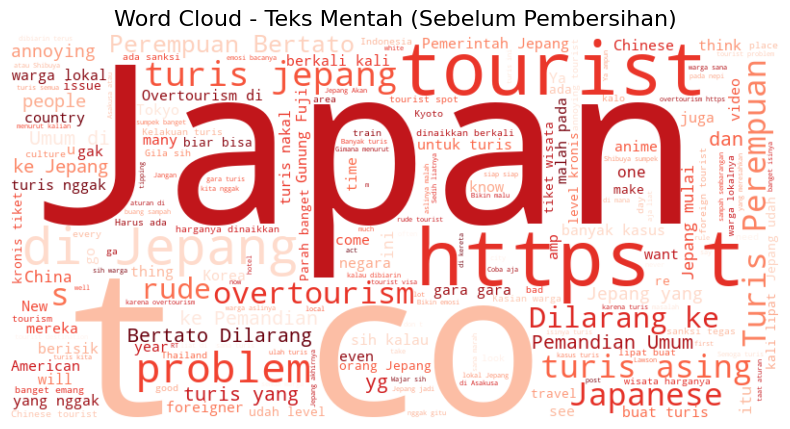

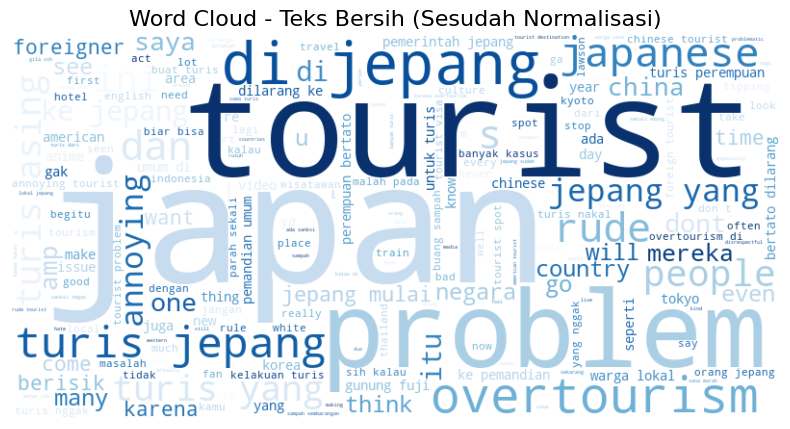

In [36]:
# Uncomment baris di bawah ini untuk menginstal pustaka jika belum ada
# !pip install wordcloud matplotlib

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Word Cloud Sebelum Pembersihan (Data Mentah)
text_raw = ' '.join(df['full_text'].dropna().astype(str).tolist())
wordcloud_raw = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_raw)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Teks Mentah (Sebelum Pembersihan)', fontsize=16)
plt.show()

# 2. Word Cloud Sesudah Pembersihan (Data Bersih & Formal)
text_clean = ' '.join(df_filtered['normalized_text'].dropna().astype(str).tolist())
wordcloud_clean = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text_clean)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Teks Bersih (Sesudah Normalisasi)', fontsize=16)
plt.show()